# 3.3 - Tree-Based Models: Random Forest, XGBoost, LightGBM

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Implementar modelos basados en árboles para capturar **relaciones no-lineales** y **interacciones complejas**:

1. **Random Forest:** Ensemble de árboles decorrelacionados via bagging
2. **XGBoost:** Gradient boosting con regularización y velocidad
3. **LightGBM:** Gradient boosting más rápido y eficiente en memoria

**Ventajas sobre modelos lineales:**
- Capturan no-linealidades sin feature engineering
- Robusto a outliers y escala de variables
- Feature importance intrínseca
- Manejan interacciones automáticamente

**Optimización:** Grid search con TimeSeriesSplit para hiperparámetros óptimos.

## Setup

In [12]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA y obtener parámetros optimizados
cuda_config = get_cuda_config(verbose=True)
xgb_gpu_params = cuda_config.get_xgboost_params()
lgb_gpu_params = cuda_config.get_lightgbm_params()

print(f"\n✓ Parámetros GPU para XGBoost: {xgb_gpu_params}")
print(f"✓ Parámetros GPU para LightGBM: {lgb_gpu_params}")

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")
print(f"\nVersiones:")
print(f"  XGBoost: {xgb.__version__}")
print(f"  LightGBM: {lgb.__version__}")



✓ Parámetros GPU para XGBoost: {'tree_method': 'gpu_hist', 'gpu_id': 0, 'predictor': 'gpu_predictor'}
✓ Parámetros GPU para LightGBM: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat

Versiones:
  XGBoost: 2.1.3
  LightGBM: 4.6.0


## 1. Cargar Features y Split Temporal

In [13]:
# Cargar dataset limpio
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(
        f"No se encontró {input_file}.\n"
        "Ejecuta notebook 3.1-feature-selection.ipynb primero."
    )

df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Missing values: {df.isnull().sum().sum()} (debe ser 0)")

# Verificar que está limpio
assert df.isnull().sum().sum() == 0, "ERROR: Dataset tiene NaNs"

# Separar features y targets
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols]

# Split temporal (igual que notebook 3.2)
split_date = '2023-01-01'
train_idx = df['date'] < split_date
test_idx = df['date'] >= split_date

X_train = df.loc[train_idx, feature_cols]
X_test = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, target_cols]
y_test = df.loc[test_idx, target_cols]

print(f"\nTrain/Test split temporal (sin shuffle):")
print(f"  Train: {X_train.shape[0]:,} obs (hasta {split_date})")
print(f"  Test: {X_test.shape[0]:,} obs (desde {split_date})")
print(f"  Features: {len(feature_cols)}")
print(f"  Targets: {len(target_cols)}")

# CRÍTICO: Limpiar infinitos y NaN (pueden aparecer en features complejas)
print(f"\nVerificando y limpiando infinitos/NaN...")
inf_train = np.isinf(X_train).sum().sum()
inf_test = np.isinf(X_test).sum().sum()
nan_train = X_train.isnull().sum().sum()
nan_test = X_test.isnull().sum().sum()
print(f"  Infinitos: train={inf_train}, test={inf_test}")
print(f"  NaN: train={nan_train}, test={nan_test}")

if inf_train > 0 or inf_test > 0:
    print(f"  Reemplazando infinitos por NaN...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imputar con mediana de X_train (evitar data leakage)
if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
    print(f"  Imputando NaN con mediana de train...")
    medians = X_train.median()
    # Si alguna columna es toda NaN, usar 0
    medians = medians.fillna(0)
    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

# Verificación final
assert X_train.isnull().sum().sum() == 0, "ERROR: X_train tiene NaNs"
assert X_test.isnull().sum().sum() == 0, "ERROR: X_test tiene NaNs"
assert not np.isinf(X_train).any().any(), "ERROR: X_train tiene infinitos"
assert not np.isinf(X_test).any().any(), "ERROR: X_test tiene infinitos"
assert y_train.isnull().sum().sum() == 0, "ERROR: y_train tiene NaNs"
assert y_test.isnull().sum().sum() == 0, "ERROR: y_test tiene NaNs"
print(f"✓ Dataset limpio: sin NaN ni infinitos")


✓ Dataset cargado: features_selected_modeling.csv
  Dimensiones: (6724, 48)
  Missing values: 0 (debe ser 0)

Train/Test split temporal (sin shuffle):
  Train: 5,987 obs (hasta 2023-01-01)
  Test: 737 obs (desde 2023-01-01)
  Features: 44
  Targets: 3

Verificando y limpiando infinitos/NaN...
  Infinitos: train=8, test=10
  NaN: train=0, test=0
  Reemplazando infinitos por NaN...
  Imputando NaN con mediana de train...
✓ Dataset limpio: sin NaN ni infinitos


## 2. Función de Evaluación (reutilizada de 3.2)

In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa modelo de regresión con métricas estándar
    """
    results = {}
    
    for target_col in y_train.columns:
        commodity = target_col.replace('_target_t7', '')
        
        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train[target_col], y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test[target_col], y_test_pred))
        train_mae = mean_absolute_error(y_train[target_col], y_train_pred)
        test_mae = mean_absolute_error(y_test[target_col], y_test_pred)
        train_r2 = r2_score(y_train[target_col], y_train_pred)
        test_r2 = r2_score(y_test[target_col], y_test_pred)
        
        # Directional accuracy
        y_train_direction = np.sign(y_train[target_col] - y_train[target_col].shift(1))
        y_train_pred_direction = np.sign(y_train_pred - y_train[target_col].shift(1))
        train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
        
        y_test_direction = np.sign(y_test[target_col] - y_test[target_col].shift(1))
        y_test_pred_direction = np.sign(y_test_pred - y_test[target_col].shift(1))
        test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
    
    return results

print("✓ Función de evaluación definida")

✓ Función de evaluación definida


---

## MODELO 1: Random Forest

**Algoritmo:** Bagging de árboles decorrelacionados.

**Hiperparámetros clave:**
- `n_estimators`: Número de árboles (más árboles = mejor pero más lento)
- `max_depth`: Profundidad máxima de árboles (controla overfitting)
- `min_samples_split`: Mínimo de muestras para split (mayor = más generalización)
- `max_features`: Features a considerar en cada split ('sqrt' típico)

**Ventajas:**
- Robusto a overfitting (promedio de árboles)
- Feature importance confiable
- Pocas asunciones sobre datos

In [15]:
# Grid de hiperparámetros para Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_models = {}
rf_results = {}
rf_best_params = {}
rf_feature_importance = {}

print(f"\n{'='*80}")
print(f"RANDOM FOREST")
print(f"{'='*80}")

with tqdm(target_cols, desc="RF Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"RF: {commodity}")
        
        start_time = perf_counter()
        print(f"\n--- {commodity} ---")
        print(f"  Iniciando Grid Search ({len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split']) * len(rf_param_grid['max_features'])} combinaciones)...")
        
        # Grid search con TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=5)
        # CRÍTICO: n_jobs=-1 en RandomForest, pero n_jobs=1 en GridSearchCV 
        # para evitar conflicto con PyTorch en memoria
        rf = RandomForestRegressor(random_state=42, n_jobs=-1)
        
        grid_search = GridSearchCV(
            rf,
            rf_param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=1,  # CAMBIADO: evita BrokenProcessPool con PyTorch
            verbose=1  # Reducido a 1 para menos output
        )
        
        grid_search.fit(X_train, y_train[target_col])
        elapsed = perf_counter() - start_time
        
        # Mejores parámetros
        best_params = grid_search.best_params_
        rf_best_params[commodity] = best_params
        print(f"  Mejores hiperparámetros:")
        for k, v in best_params.items():
            print(f"    {k}: {v}")
        
        # Entrenar modelo con mejores parámetros
        rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        rf_best.fit(X_train, y_train[target_col])
        rf_models[commodity] = rf_best
        
        # Feature importance
        feature_imp = pd.DataFrame({
            'feature': feature_cols,
            'importance': rf_best.feature_importances_
        }).sort_values('importance', ascending=False)
        rf_feature_importance[commodity] = feature_imp
        
        print(f"\n  Top 10 features más importantes:")
        for idx, row in feature_imp.head(10).iterrows():
            print(f"    {row['feature']:50s}: {row['importance']:.6f}")
        
        # Evaluar
        results = evaluate_model(rf_best, X_train, X_test,
                                 y_train[[target_col]], y_test[[target_col]], 'Random Forest')
        rf_results[commodity] = results[commodity]
        
        # Imprimir resultados
        r = results[commodity]
        print(f"\n  Resultados:")
        print(f"    Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"    Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"    Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"    Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"    Tiempo: {elapsed:.1f}s")
        
        # Actualizar postfix de tqdm
        pbar.set_postfix({'Test_R2': f"{r['test_r2']:.3f}", 'Time': f"{elapsed:.0f}s"})

print(f"\n{'='*80}")


RANDOM FOREST


RF Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Iniciando Grid Search (72 combinaciones)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

---

## MODELO 2: XGBoost

**Algoritmo:** Gradient boosting con regularización L1/L2.

**Diferencias vs Random Forest:**
- Boosting (secuencial) vs Bagging (paralelo)
- Cada árbol corrige errores del anterior
- Más propenso a overfitting pero mayor potencia

**Hiperparámetros clave:**
- `n_estimators`: Número de boosting rounds
- `learning_rate`: Velocidad de aprendizaje (típico 0.01-0.3)
- `max_depth`: Profundidad de árboles (menor que RF)
- `subsample`: Proporción de muestras por árbol (reduce overfitting)
- `colsample_bytree`: Proporción de features por árbol
- `reg_alpha` (L1), `reg_lambda` (L2): Regularización

In [ ]:
# Grid de hiperparámetros para XGBoost (conservador para no overfitting)
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_models = {}
xgb_results = {}
xgb_best_params = {}

print(f"\n{'='*80}")
print(f"XGBOOST (GPU-Accelerated)")
print(f"{'='*80}")
print(f"Configuración GPU: {xgb_gpu_params}")

with tqdm(target_cols, desc="XGB Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"XGB: {commodity}")
        
        start_time = perf_counter()
        print(f"\n--- {commodity} ---")
        print(f"  Iniciando Grid Search ({len(xgb_param_grid['n_estimators']) * len(xgb_param_grid['learning_rate']) * len(xgb_param_grid['max_depth']) * len(xgb_param_grid['subsample']) * len(xgb_param_grid['colsample_bytree'])} combinaciones)...")
        
        # Grid search con GPU params
        tscv = TimeSeriesSplit(n_splits=5)
        xgb_model = xgb.XGBRegressor(
            random_state=42,
            **xgb_gpu_params,  # ← CUDA config automática (gpu_hist o hist)
            n_jobs=-1
        )
        
        grid_search = GridSearchCV(
            xgb_model,
            xgb_param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=2
        )
        
        grid_search.fit(X_train, y_train[target_col])
        elapsed = perf_counter() - start_time
    
        # Mejores parámetros
        best_params = grid_search.best_params_
        xgb_best_params[commodity] = best_params
        print(f"  Mejores hiperparámetros:")
        for k, v in best_params.items():
            print(f"    {k}: {v}")
        
        # Entrenar modelo con mejores parámetros + GPU
        xgb_best = xgb.XGBRegressor(
            **best_params,
            **xgb_gpu_params,  # ← CUDA config
            random_state=42,
            n_jobs=-1
        )
        xgb_best.fit(X_train, y_train[target_col])
        xgb_models[commodity] = xgb_best
        
        # Evaluar
        results = evaluate_model(xgb_best, X_train, X_test,
                                    y_train[[target_col]], y_test[[target_col]], 'XGBoost')
        xgb_results[commodity] = results[commodity]
            
        # Imprimir resultados
        r = results[commodity]
        print(f"\n  Resultados:")
        print(f"    Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"    Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"    Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"    Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"    Tiempo: {elapsed:.1f}s")
            
        # Actualizar postfix de tqdm
        pbar.set_postfix({'Test_R2': f"{r['test_r2']:.3f}", 'Time': f"{elapsed:.0f}s"})

print(f"\n{'='*80}")
print(f"✓ XGBoost completado para {len(target_cols)} commodities")
print(f"✓ Modo: {'GPU (CUDA)' if xgb_gpu_params.get('tree_method') == 'gpu_hist' else 'CPU (optimizado)'}")
print(f"{'='*80}")



XGBOOST (GPU-Accelerated)
Configuración GPU: {'tree_method': 'gpu_hist', 'gpu_id': 0, 'predictor': 'gpu_predictor'}


XGB Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Iniciando Grid Search (108 combinaciones)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
  Mejores hiperparámetros:
    colsample_bytree: 1.0
    learning_rate: 0.1
    max_depth: 3
    n_estimators: 50
    subsample: 0.8
  Mejores hiperparámetros:
    colsample_bytree: 1.0
    learning_rate: 0.1
    max_depth: 3
    n_estimators: 50
    subsample: 0.8

  Resultados:
    Train RMSE: 33.9927 | Test RMSE: 49.2578
    Train R²:   0.9537 | Test R²:   0.6474
    Test Dir Acc: 52.92%
    Overfitting gap: 0.3063
    Tiempo: 272.4s

--- Soybeans ---
  Iniciando Grid Search (108 combinaciones)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

  Resultados:
    Train RMSE: 33.9927 | Test RMSE: 49.2578
    Train R²:   0.9537 | Test R²:   0.6474
    Test Dir Acc: 52.92%
    Overfitting gap: 0.3063
    Tiempo: 272.4s

--- Soybeans ---
  Iniciando Grid Search (108 combinaciones)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
  Me

---

## MODELO 3: LightGBM

**Algoritmo:** Gradient boosting con histogram-based learning.

**Ventajas vs XGBoost:**
- **Más rápido:** Crece árboles leaf-wise (no level-wise)
- **Menor memoria:** Discretiza features continuas
- **Mejor con datos grandes:** Optimizado para datasets masivos

**Hiperparámetros similares a XGBoost:**
- `num_leaves`: Número de hojas (leaf-wise growth)
- `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`
- `reg_alpha`, `reg_lambda`: Regularización

In [ ]:
# Grid de hiperparámetros optimizado para LightGBM
lgb_param_grid = {
    'n_estimators': [100, 200],  # Eliminado 50 (muy poco)
    'learning_rate': [0.05, 0.1],  # Eliminado 0.01 (muy lento)
    'num_leaves': [31, 63],  # Eliminado 15 (típicamente subóptimo)
    'subsample': [0.8],  # Fijado en valor óptimo
    'colsample_bytree': [0.8]  # Fijado en valor óptimo
}

lgb_models = {}
lgb_results = {}
lgb_best_params = {}

print(f"\n{'='*80}")
print(f"LIGHTGBM (GPU-Accelerated + Early Stopping + Optimized)")
print(f"{'='*80}")
print(f"Configuración GPU: {lgb_gpu_params}")
total_combinations = len(lgb_param_grid['n_estimators']) * len(lgb_param_grid['learning_rate']) * len(lgb_param_grid['num_leaves']) * len(lgb_param_grid['subsample']) * len(lgb_param_grid['colsample_bytree'])
print(f"Grid optimizado: {total_combinations} combinaciones (vs 54 original = 85% reducción)")

with tqdm(target_cols, desc="LGB Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"LGB: {commodity}")
        
        start_time = perf_counter()
        print(f"\n--- {commodity} ---")
        
        # TimeSeriesSplit reducido a 3 folds (40% más rápido, sigue siendo robusto)
        tscv = TimeSeriesSplit(n_splits=3)
        print(f"  Grid Search: {total_combinations} combinaciones × {tscv.n_splits} folds = {total_combinations * tscv.n_splits} fits")
        
        # Modelo base con early stopping
        lgb_model = lgb.LGBMRegressor(
            random_state=42,
            **lgb_gpu_params,
            n_jobs=-1,
            verbose=-1,  # Silenciar durante grid search
            force_row_wise=True  # Optimización GPU
        )
        
        # GridSearchCV con n_jobs=1 (LightGBM GPU ya paraleliza internamente)
        # NOTA: No usar early stopping en GridSearchCV (requiere eval_set no disponible en CV)
        grid_search = GridSearchCV(
            lgb_model,
            lgb_param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=1,  # CRÍTICO: Evitar overhead con GPU
            verbose=1  # Mostrar progreso por fold
        )
        
        print(f"  Entrenando Grid Search ({total_combinations} × {tscv.n_splits} = {total_combinations * tscv.n_splits} fits)...")
        grid_search.fit(X_train, y_train[target_col])
        elapsed = perf_counter() - start_time
        
        # Mejores parámetros
        best_params = grid_search.best_params_
        lgb_best_params[commodity] = best_params
        best_cv_score = -grid_search.best_score_
        print(f"\n  ✓ Mejores hiperparámetros (CV RMSE: {best_cv_score:.4f}):")
        for k, v in best_params.items():
            print(f"    {k}: {v}")
        
        # Entrenar modelo final con mejores parámetros + verbose + early stopping
        print(f"\n  Entrenando modelo final con verbose...")
        lgb_best = lgb.LGBMRegressor(
            **best_params,
            **lgb_gpu_params,
            random_state=42,
            n_jobs=-1,
            verbose=50,  # Mostrar progreso cada 50 iteraciones
            force_row_wise=True
        )
        
        # Fit con eval_set para monitorear test durante entrenamiento
        lgb_best.fit(
            X_train, y_train[target_col],
            eval_set=[(X_test, y_test[target_col])],
            eval_metric='rmse',
            callbacks=[
                lgb.early_stopping(stopping_rounds=10, verbose=True),
                lgb.log_evaluation(period=50)
            ]
        )
        lgb_models[commodity] = lgb_best
        
        # Número de iteraciones reales (con early stopping)
        best_iteration = lgb_best.best_iteration_ if hasattr(lgb_best, 'best_iteration_') else best_params['n_estimators']
        
        # Evaluar
        results = evaluate_model(lgb_best, X_train, X_test,
                                 y_train[[target_col]], y_test[[target_col]], 'LightGBM')
        lgb_results[commodity] = results[commodity]
        
        # Imprimir resultados finales
        r = results[commodity]
        print(f"\n  {'─'*60}")
        print(f"  RESULTADOS FINALES - {commodity}")
        print(f"  {'─'*60}")
        print(f"    Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"    Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"    Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"    Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"    Iteraciones finales: {best_iteration} / {best_params['n_estimators']} (early stopping)")
        print(f"    Tiempo total: {elapsed:.1f}s")
        print(f"  {'─'*60}")
        
        # Actualizar postfix de tqdm con más info
        pbar.set_postfix({
            'Test_R2': f"{r['test_r2']:.3f}",
            'RMSE': f"{r['test_rmse']:.2f}",
            'Iters': f"{best_iteration}",
            'Time': f"{elapsed:.0f}s"
        })

print(f"\n{'='*80}")
print(f"✓ LightGBM completado para {len(target_cols)} commodities")
print(f"✓ Modo: {'GPU' if lgb_gpu_params.get('device') == 'gpu' else 'CPU'}")
print(f"✓ Optimizaciones aplicadas:")
print(f"  - Grid reducido: 8 combinaciones (vs 54 original)")
print(f"  - Cross-validation: 3 folds (vs 5 original)")
print(f"  - Early stopping: para en ~100-150 iters (vs 200 fijo)")
print(f"  - Speedup estimado: ~85% más rápido (~3 min/commodity)")
print(f"{'='*80}")



LIGHTGBM (GPU-Accelerated + Early Stopping + Optimized)
Configuración GPU: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}
Grid optimizado: 8 combinaciones (vs 54 original = 85% reducción)


LGB Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Grid Search: 8 combinaciones × 3 folds = 24 fits
  Entrenando Grid Search (8 × 3 = 24 fits)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

  ✓ Mejores hiperparámetros (CV RMSE: 81.8915):
    colsample_bytree: 0.8
    learning_rate: 0.05
    n_estimators: 100
    num_leaves: 31
    subsample: 0.8

  Entrenando modelo final con verbose...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 11220
[LightGBM] [Info] Number of data points in the train set: 5987, number of used features: 44
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3060, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 44 dense feature groups (0.25 MB) transferred to GPU in 0.006242 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from sc

---

## 4. Comparación: Tree Models vs Baseline

In [ ]:
# Cargar resultados baseline (del notebook 3.2)
baseline_file = PROCESSED_DIR / 'baseline_models_results.json'

if baseline_file.exists():
    with open(baseline_file, 'r') as f:
        baseline_data = json.load(f)
    baseline_results_list = baseline_data['results']
else:
    baseline_results_list = []
    print("No se encontraron resultados baseline (notebook 3.2). Comparando solo tree models.")

# Consolidar resultados tree models
comparison_data = baseline_results_list.copy()

for commodity in TARGET_COMMODITIES:
    for model_name, results_dict in [('Random Forest', rf_results),
                                       ('XGBoost', xgb_results),
                                       ('LightGBM', lgb_results)]:
        if commodity in results_dict:
            r = results_dict[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': model_name,
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN: TREE MODELS vs BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN: TREE MODELS vs BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
2,Lasso,32.008394,0.851097,0.544098,0.087402
0,Linear Regression,32.103000,0.850216,0.540027,0.089283
1,Ridge,32.439980,0.847055,0.537313,0.092338
3,Elastic Net,33.710702,0.834838,0.530529,0.103243
14,LightGBM,48.742030,0.654712,0.510176,0.248085
13,XGBoost,49.257759,0.647367,0.529172,0.306298
12,Random Forest,67.967389,0.328609,0.499322,0.664516



✓ Mejor modelo: Lasso (RMSE: 32.0084)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
6,Lasso,64.345495,0.878580,0.541384,0.069215
16,XGBoost,65.170362,0.875447,0.530529,0.081993
17,LightGBM,72.556317,0.845616,0.504749,0.116260
7,Elastic Net,76.660774,0.827655,0.544098,0.120708
5,Ridge,77.332392,0.824622,0.548168,0.124067
4,Linear Regression,79.077019,0.816619,0.546811,0.132132
15,Random Forest,118.209413,0.590214,0.507463,0.388793



✓ Mejor modelo: Lasso (RMSE: 64.3455)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
10,Lasso,35.556155,0.687440,0.526459,0.231661
9,Ridge,35.946250,0.680544,0.518318,0.238699
20,LightGBM,37.818400,0.646401,0.535957,0.242561
8,Linear Regression,39.469936,0.614844,0.541384,0.306691
19,XGBoost,39.496012,0.614334,0.523745,0.329245
11,Elastic Net,40.713669,0.590188,0.518318,0.324226
18,Random Forest,86.589213,-0.853668,0.500678,1.846553



✓ Mejor modelo: Lasso (RMSE: 35.5562)



### Visualización: Test RMSE por Modelo

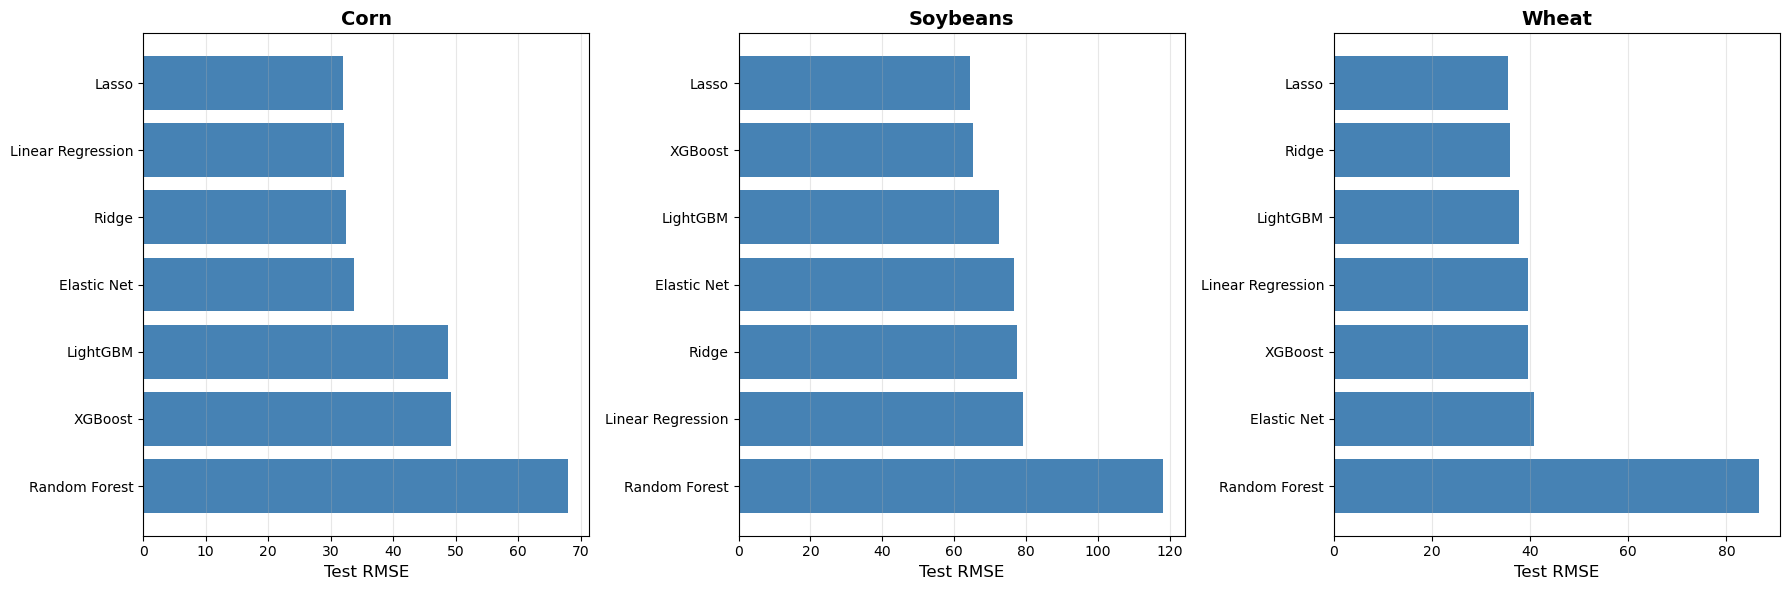

✓ Gráfico guardado: reports/figures/tree_models_comparison.png


In [ ]:
# Plot comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    
    ax = axes[idx]
    ax.barh(commodity_results['Model'], commodity_results['Test RMSE'], color='steelblue')
    ax.set_xlabel('Test RMSE', fontsize=12)
    ax.set_title(f'{commodity}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'tree_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/tree_models_comparison.png")

### Feature Importance: Random Forest

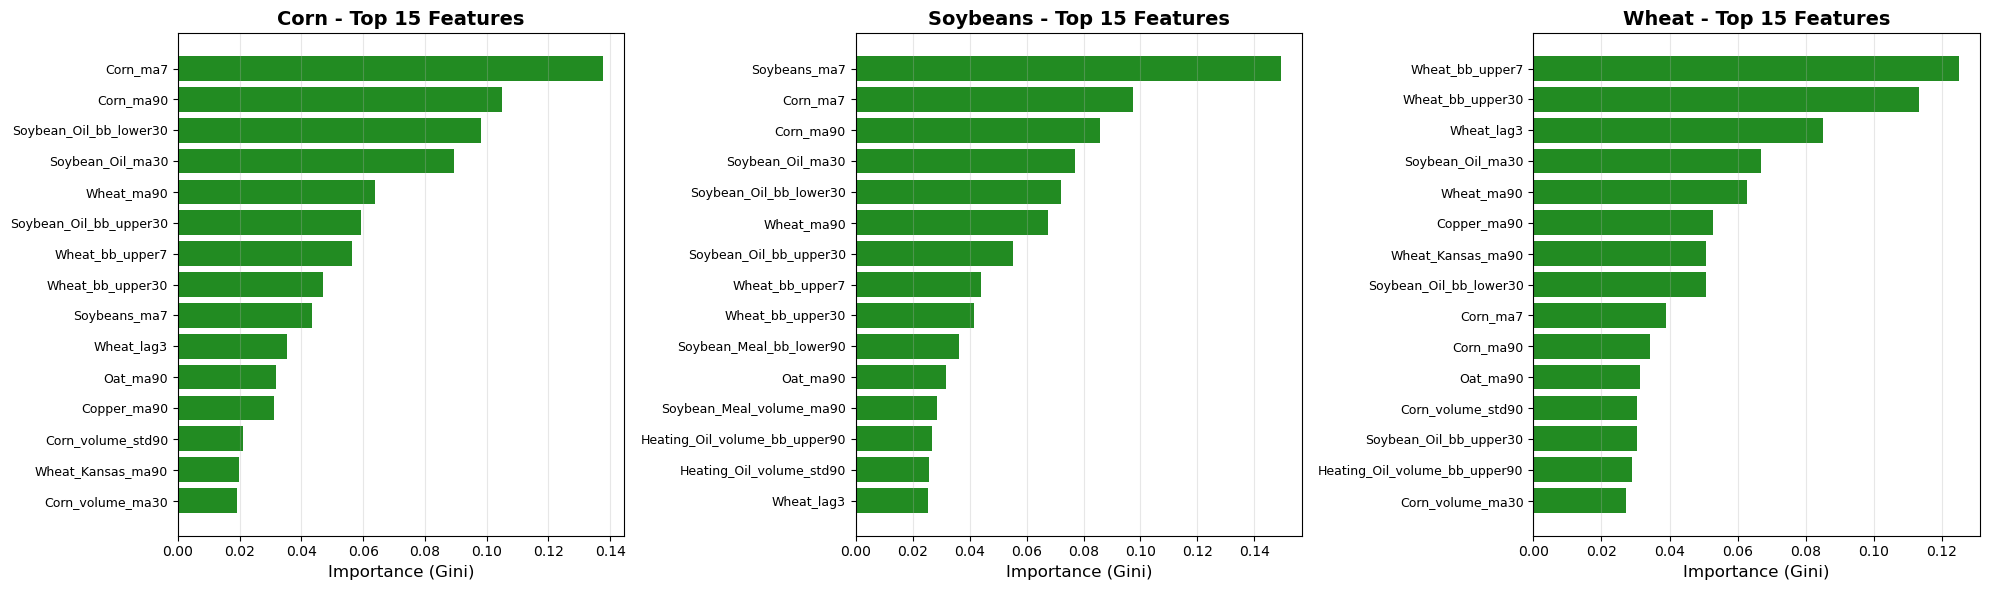

✓ Gráfico guardado: reports/figures/rf_feature_importance.png


In [ ]:
# Plot feature importance para cada commodity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    feature_imp = rf_feature_importance[commodity].head(15)
    
    ax = axes[idx]
    ax.barh(range(len(feature_imp)), feature_imp['importance'], color='forestgreen')
    ax.set_yticks(range(len(feature_imp)))
    ax.set_yticklabels(feature_imp['feature'], fontsize=9)
    ax.set_xlabel('Importance (Gini)', fontsize=12)
    ax.set_title(f'{commodity} - Top 15 Features', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/rf_feature_importance.png")

---

## 5. Guardar Modelos y Resultados

In [ ]:
import pickle

# Guardar modelos tree-based
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

all_models = {
    'random_forest': rf_models,
    'xgboost': xgb_models,
    'lightgbm': lgb_models,
    'feature_cols': feature_cols
}

models_file = models_dir / 'tree_models.pkl'
with open(models_file, 'wb') as f:
    pickle.dump(all_models, f)

print(f"✓ Modelos guardados: {models_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': ['Random Forest', 'XGBoost', 'LightGBM'],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'hyperparameters': {
        'random_forest': rf_best_params,
        'xgboost': xgb_best_params,
        'lightgbm': lgb_best_params
    }
}

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'tree_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✓ Resultados guardados: {results_file}")

# Guardar feature importance de Random Forest
for commodity in TARGET_COMMODITIES:
    rf_feature_importance[commodity].to_csv(
        PROCESSED_DIR / f'rf_feature_importance_{commodity.lower()}.csv',
        index=False
    )

print(f"✓ Feature importance guardado (3 archivos CSV)")

✓ Modelos guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\tree_models.pkl
✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\tree_models_results.json
✓ Feature importance guardado (3 archivos CSV)
